In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans,AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, calinski_harabasz_score,davies_bouldin_score

from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import DBSCAN



import mlflow
import mlflow.sklearn

RANDOM_STATE = 42


sns.set(style="whitegrid")

In [2]:
url = "Data/CC GENERAL.csv"
df = pd.read_csv(url)
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.drop(columns=['CUST_ID'], inplace=True)

In [4]:
df = df.dropna(subset=["CREDIT_LIMIT"])

In [5]:
log_transform = FunctionTransformer(np.log1p, validate=False)

log_columns = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'PURCHASES_TRX'
]

normal_columns =[
    'BALANCE_FREQUENCY',
    'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

In [6]:
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transform),
    ("scaler", StandardScaler())
])

normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [7]:
processor = ColumnTransformer([
    ("log_features", log_pipeline, log_columns),

    ("normal_features", normal_pipeline, normal_columns )
])

In [8]:
processor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_features', ...), ('normal_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [9]:
numeric_features = [
    'BALANCE',
    'BALANCE_FREQUENCY',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PURCHASES_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',
    'CASH_ADVANCE_TRX',
    'PURCHASES_TRX',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

preprocess_pipeline = Pipeline([
    ("preprocessor", processor)
])

In [10]:
preprocess_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_features', ...), ('normal_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [11]:
X_scaled = preprocess_pipeline.fit_transform(df)

In [12]:
pca = PCA(n_components=17, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)

In [13]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

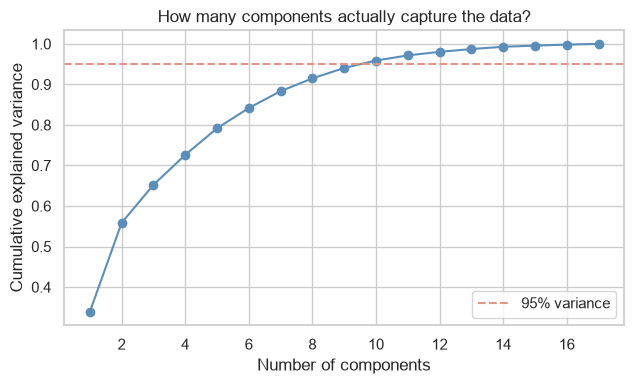

Components needed for 95% variance: 10 (out of 17)


In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, "o-", color="#5B8FB9")
ax.axhline(0.95, color="#E39482", linestyle="--", label="95% variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("How many components actually capture the data?")
ax.legend()
plt.tight_layout()
plt.show()

n_comp_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_comp_95} (out of {X_pca.shape[1]})")

In [27]:
pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

In [15]:
mlflow.set_tracking_uri('sqlite:///mlflow_credit_card_clustering.db')
mlflow.set_experiment('Credit Card Clustering')

2026/07/24 10:08:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/24 10:08:03 INFO mlflow.store.db.utils: Updating database tables
2026/07/24 10:08:04 INFO mlflow.tracking.fluent: Experiment with name 'Credit Card Clustering' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Training/Week 3/Project/Credit-Card-Customer-Segmentation/mlruns/1', creation_time=1784884084791, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784884084791, lifecycle_stage='active', name='Credit Card Clustering', tags={}, trace_location=None, workspace='default'>

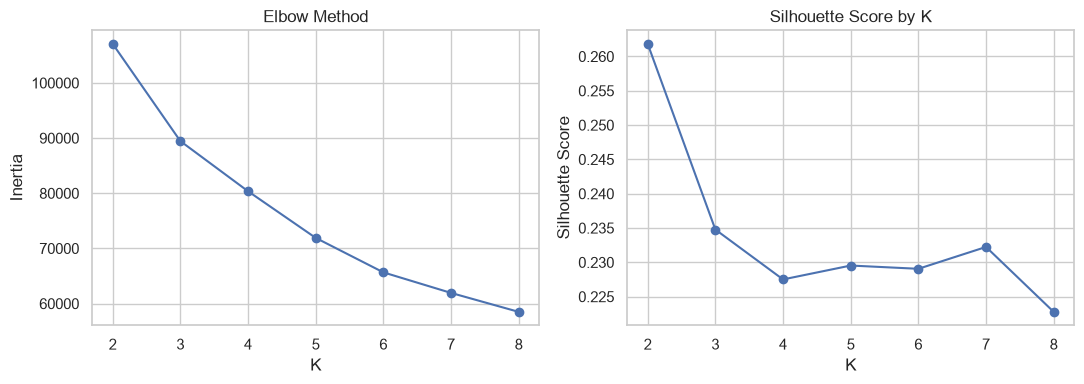

In [28]:
K_range = range(2, 9)
inertias = []
sil_scores = []

for k in K_range:
    with mlflow.start_run(run_name=f"KMeans_k={k}"):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_pca)

        inertia = km.inertia_
        silhouette = silhouette_score(X_pca, labels)

        inertias.append(inertia)
        sil_scores.append(silhouette)

        mlflow.log_param("algorithm", "KMeans")
        mlflow.log_param("dataset", "X_pca")
        mlflow.log_param("k", k)
        mlflow.log_param('n_init',10)
        mlflow.log_param('pca_components',10)
        

        mlflow.log_metric("inertia", inertia)
        mlflow.log_metric("silhouette", silhouette)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(K_range, inertias, "o-")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(K_range, sil_scores, "o-")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")

plt.tight_layout()
fig.savefig("kmeans_evaluation.png")
mlflow.log_artifact("kmeans_evaluation.png")
mlflow.end_run()
plt.show()



In [ ]:
K_range = range(2, 9)
sil_scores = []

for k in K_range:
    with mlflow.start_run(run_name=f"Hierarchical_k={k}_PCA"):
        agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
        )

        labels = agg.fit_predict(X_pca)
        silhouette = silhouette_score(X_pca, labels)
        sil_scores.append(silhouette)

        mlflow.log_param("algorithm", "Agglomerative")
        mlflow.log_param("dataset", "X_pca")
        mlflow.log_param("k", k)
        mlflow.log_param("linkage", "ward")
        mlflow.log_metric("silhouette_score", silhouette)
        mlflow.end_run()


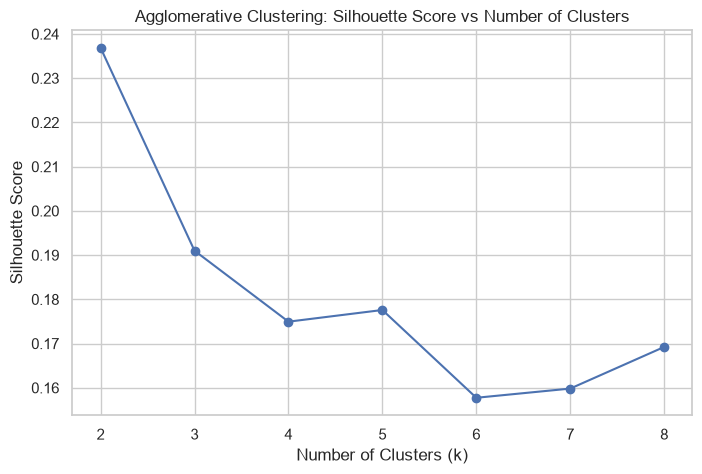

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, marker="o")
plt.title("Agglomerative Clustering: Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range)
plt.grid(True)
plt.show()

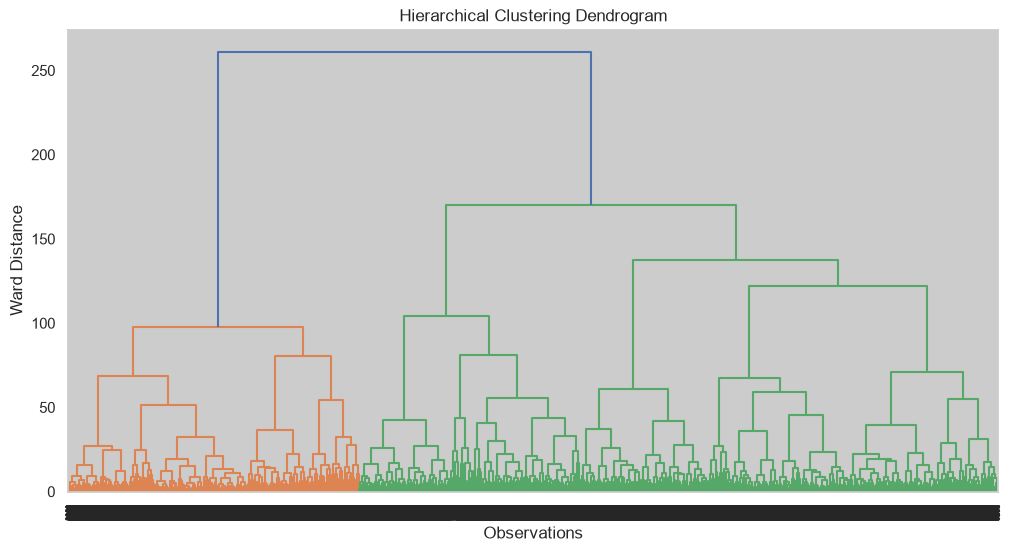

In [32]:
linked = linkage(X_pca, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Ward Distance")
plt.show()

In [35]:
eps_values = np.arange(0.1, 2.1, 0.1)
sil_scores = []
n_clusters_list = []
noise_points = []

for eps in eps_values:
    with mlflow.start_run(run_name=f"DBSCAN_eps={eps:.1f}_PCA"):
        dbscan = DBSCAN(
            eps=eps,
            min_samples=5
        )

        labels = dbscan.fit_predict(X_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if n_clusters >= 2:
            silhouette = silhouette_score(X_pca, labels)
        else:
            silhouette = np.nan

        sil_scores.append(silhouette)
        n_clusters_list.append(n_clusters)
        noise_points.append(n_noise)

        mlflow.log_param("algorithm", "DBSCAN")
        mlflow.log_param("dataset", "X_pca")
        mlflow.log_param("eps", eps)
        mlflow.log_param("min_samples", 5)

        mlflow.log_metric("n_clusters", n_clusters)
        mlflow.log_metric("noise_points", n_noise)

        if not np.isnan(silhouette):
            mlflow.log_metric("silhouette_score", silhouette)

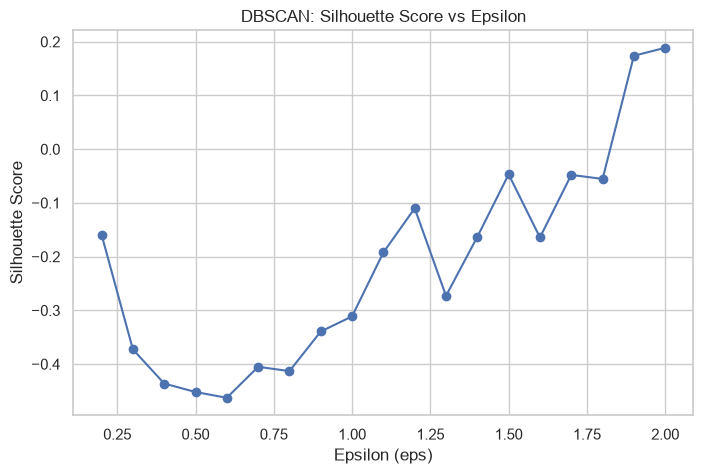

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(eps_values, sil_scores, marker="o")
plt.title("DBSCAN: Silhouette Score vs Epsilon")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

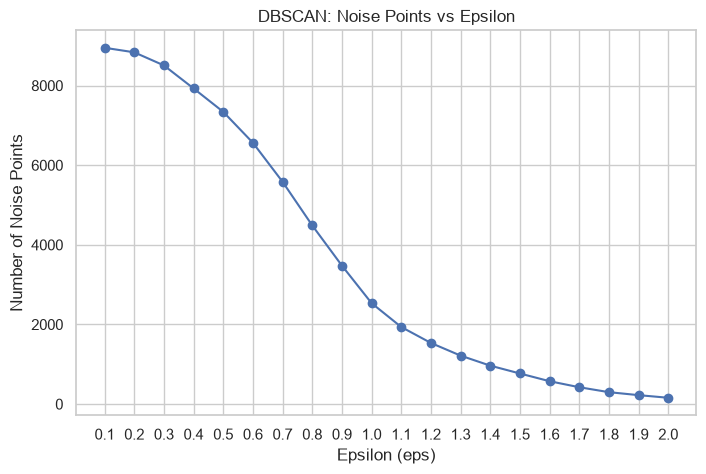

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(eps_values, noise_points, marker="o")
plt.title("DBSCAN: Noise Points vs Epsilon")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Number of Noise Points")
plt.xticks(eps_values)
plt.grid(True)
plt.show()